<a href="https://colab.research.google.com/github/kevinquiosc-rgb/Projectos_Kevin/blob/main/Proyecto_final_de_curso_Demanda_de_Ventas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO FINAL DE PROYECCION DE DEMANDA DE VENTAS

El presente NOTEBOOK es un proyecto final de curso de analisis de series temporales, se realizo un analisis completo para estimar la demanda de ventas de una empresa con multiples tiendas, con mas de 913 mil registros por tienda un ejemplo de BIG DATA y series temporales.

Se realizó un proceso completo de analisis estadistico pasando por enfocar un analisis centrado en una sola tienda y uno de los 28 productos disponibles, realizando

1. Proceso de carga de datos ETL
2. Analisis Exploratorio de datos
3. Analisis de series temporales
6. Ajuste y Comparacion de modelos TRIPLE SUAV EXP - Trans Log - ARIMA
7. Presentacion del mejor modelo

1. El proceso ETL consistió en cargar la base que tenia un tipo de encodificacion, formato CSV separados con punto y coma, ademas existen columnas vacias que fueron retiradas, tambien se cambio el tipo de dato numero a ENTERO para evitar errores y se etiquetaron los datos, dentro de las 10 tiendas se escogio la tienda 2 y de los productos a proyectar se escogió el producto nro 28 se indexaron y acumularon las ventas por MES la cual comprende el periodo del año 2013 al 2017.

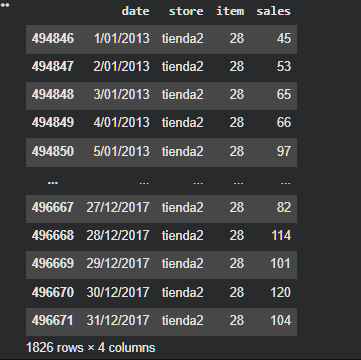

2. El analisis exploratorio grafico muestra una tendencia ascendente y una estacionalidad marcada idoneos para el analisis de series temporales, ademas tambien muestra una distribucion normal a lo largo de los meses.

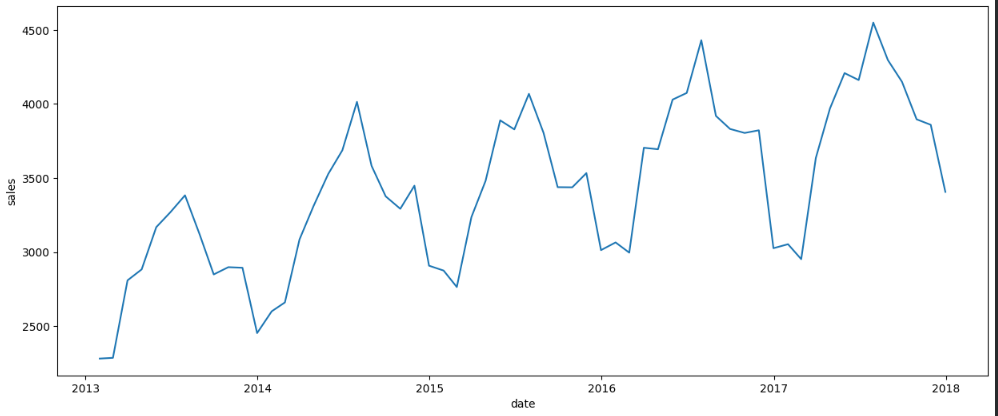

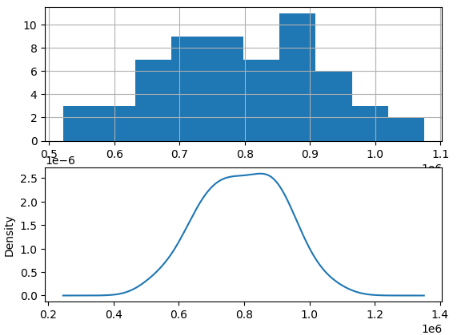

3. El analisis de series temporales confirma la tendencia y la estacionalidad  que junto con la normalidad y dickey/fuller(prueba de estacionariedad)  y eso nos da pie a realizar modelos clasicos como ARIMA.

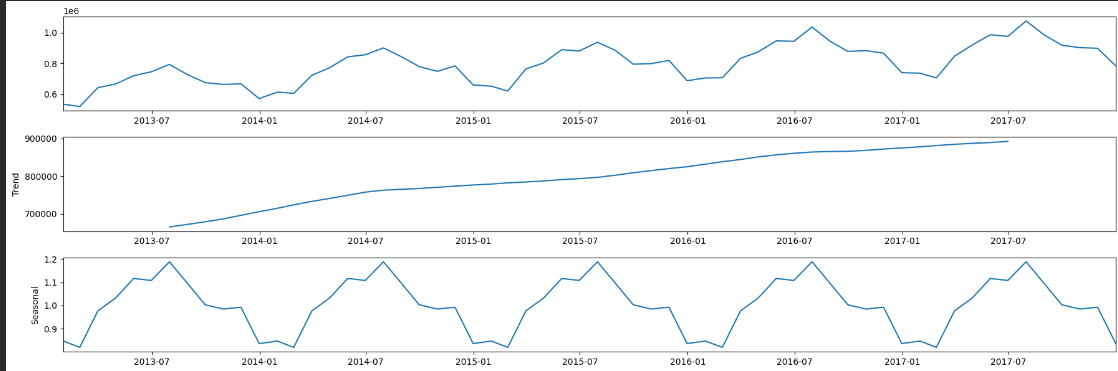

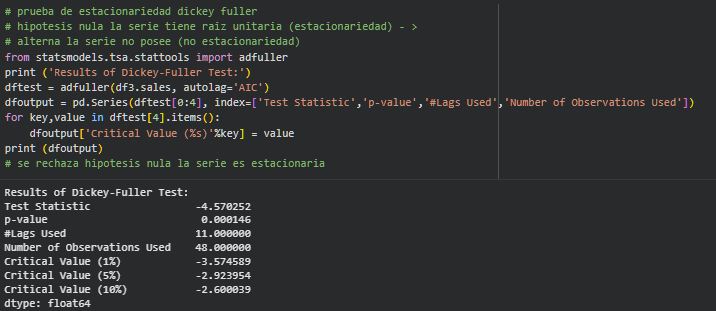

4. En el ajuste de modelos se estimaron los ajustes de los modelos TRIPLE SUAV EXP, HOLT WINTERS Y ARIMA.

PROPHET

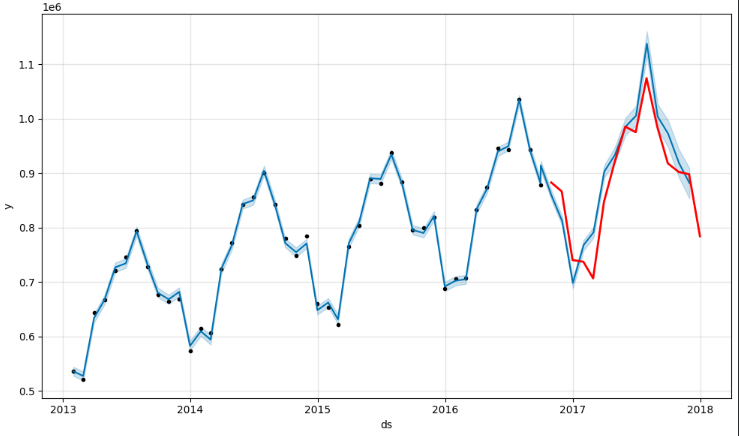

TRIPLE SUAVIZADO EXPONENCIAL

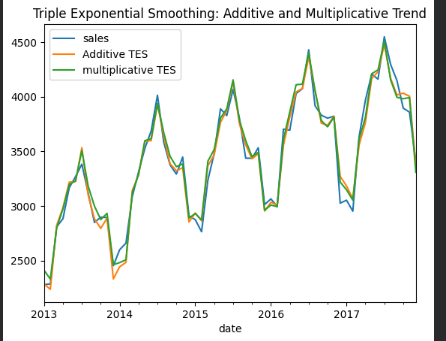

HOLT WINTERS

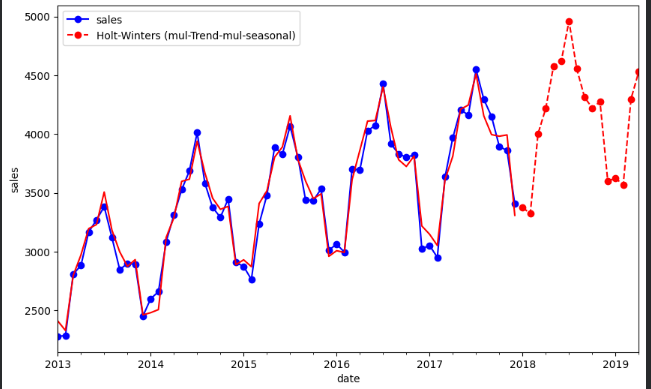

ARIMA

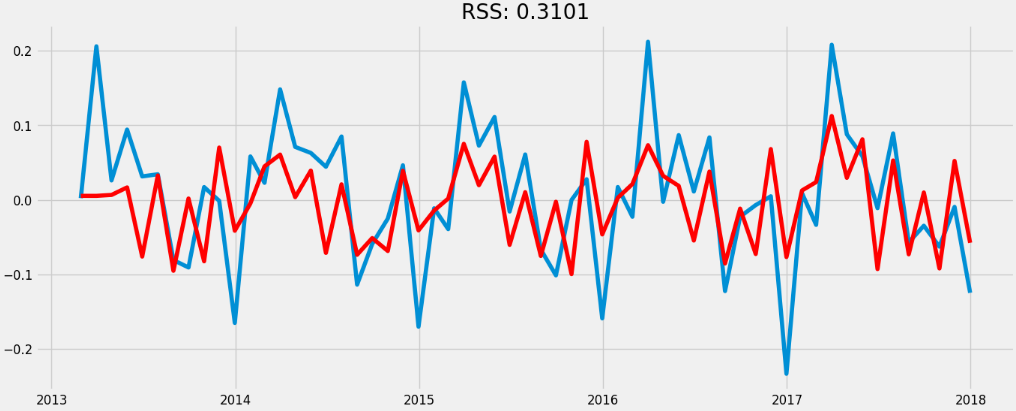

5. MERICAS DE BONDAD DE AJUSTE - EL EJOR MODELOFUE EL SUAVIZADO EXP ADIIVO Y MULTIPLICATIVO

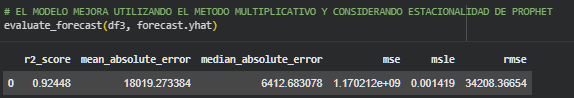

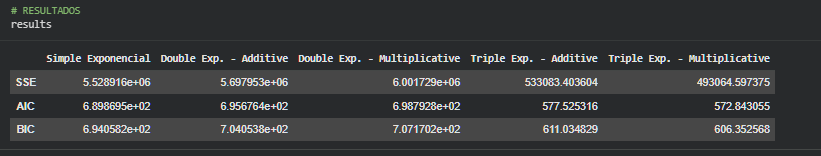

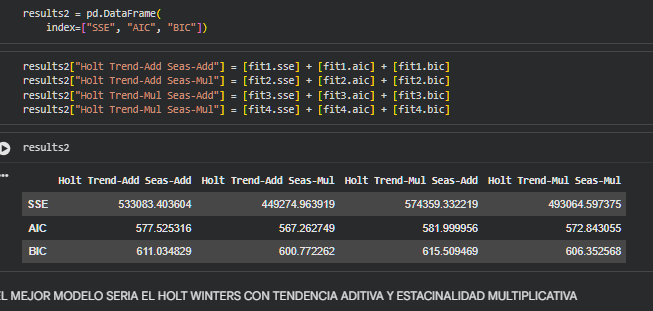

# Proceso de ETL

In [ ]:
## CARGA DE CSV EN DF
df = pd.read_csv('/content/drive/MyDrive/SERIES TEMPORALES/SalesDemand-examen.csv',encoding='latin-1', sep = ';')

In [ ]:
# COLUMNAS DF
df.info()

In [ ]:
# PRIMERA VISTA DF
df.head()

In [ ]:
# COLA DF
df.tail()

In [ ]:
# proporcion de store en sales para seleccionar1 - escojo el 8
df.groupby('store')['sales'].sum() / df['sales'].sum()

In [ ]:
# proporcion de productos para seleccionar 1 - escojo el 28
df.groupby('item')['sales'].sum() / df['sales'].sum()

In [ ]:
# CONTAR NAN
df.value_counts(dropna=False)

In [ ]:
# LIMPIAR NA EN DF
df = df.dropna(how='all')
df.value_counts(dropna=False)

In [ ]:
# % DE STORES
df['store'].value_counts()/df['store'].value_counts().sum()

In [ ]:
# TOTAL DE STORES
df.store.value_counts(dropna=False)

In [ ]:
## TRANSFORMAR STORE EN TXT
df['store'] = df['store'].replace([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0],
 ["tienda1","tienda2","tienda3","tienda4","tienda5","tienda6","tienda7","tienda8","tienda9","tienda10"])

In [ ]:
# % DE STORES escojo la tienda 8 para analizar
df.groupby('store')['sales'].sum() / df['sales'].sum()

In [ ]:
# VALIDACION DE NA
df.value_counts(dropna=False)

In [ ]:
df.tail()

In [ ]:
# VALIDAR LIMPIEZA
df.info()

In [ ]:
# PERIODO INICIO A FIN
print('Inicio de periodo: {}\nPeriodo Final: {}'.format(df.date.min(),df.date.max()))

In [ ]:
df.info()

In [ ]:
df.value_counts(dropna=False)

In [ ]:
# CAMBIO DE TIPO DE ITEM Y SALES
df['item'] = df['item'].astype(int)
df['sales'] = df['sales'].astype(int)

In [ ]:
# VALIDACION DE TIPO
df.dtypes

In [ ]:
# SEPARANDO DF A TRABAJAR, TIENDA 2 Y PRODUCTO 28 EN OTRO DATAFRAME
df1 = df[(df['store'] == 'tienda2') & (df['item'] ==28)]
df1

In [ ]:
##retirando columna item (que ya definimos como producto nro 28 y tienda2)
df2 = df1[['date','sales']]
df2

In [ ]:
# SETEANDO FECHAS A INDEX
df2.set_index('date', inplace=True)
df2.index = pd.to_datetime(df2.index)

In [ ]:
# RESAMPLEANDO A DATA MENSUAL ACUMULANDO VENTAS
df3 = df2.resample('M').sum()

In [ ]:
# VALIDANDO SAMPLEADO
df3

# ANALISIS EXPLORATORIO

In [ ]:
# Visualizando datos completos mensuales (ventas mensuales de la tienda 2 producto 28)
fig, ax = plt.subplots(figsize=(15,6))
sns.lineplot(x = df3.index, y= df3.sales, ax=ax)
pyplot.show()

In [ ]:
# HISTOGRAMA Y DENSIDAD - habria normalidad
pyplot.figure(1)
pyplot.subplot(211)
df3.sales.hist()
pyplot.subplot(212)
df3.sales.plot(kind='kde')
pyplot.show()

In [ ]:
# CAJAS Y BIGOTES
fig, ax = plt.subplots(figsize=(15,6))
sns.boxplot(x= df3.index.year,y= df3.sales, ax=ax)
pyplot.show()

# ANALISIS DE SERIES TEMPORALES

In [ ]:
# DESCOMPOSICION CLASICA DE LA SERIE
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib
decomposition = sm.tsa.seasonal_decompose(df3, model='multiplicative')
matplotlib.rcParams['figure.figsize'] = 18, 8
fig = decomposition.plot()
plt.show()

In [ ]:
## SE EVIDENCIA TENDENCIA Y ESTACIONALIDAD

In [ ]:
## RESIDUALES
decomposition.resid.plot()

In [ ]:
# OBSERVANDO EL MODELO ADITIVO
from pylab import rcParams
matplotlib.rcParams['figure.figsize'] = 18, 8
decomposition = sm.tsa.seasonal_decompose(df3, model='aditive')
fig = decomposition.plot()
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

pyplot.figure()
pyplot.subplot(211)
plot_acf(df3.sales, ax=pyplot.gca(), lags = 30)
pyplot.subplot(212)
plot_pacf(df3.sales, ax=pyplot.gca(), lags = 20)
pyplot.show()

In [ ]:
# prueba de estacionariedad dickey fuller
# hipotesis nula la serie tiene raiz unitaria (estacionariedad) - >
# alterna la serie no posee (no estacionariedad)
from statsmodels.tsa.stattools import adfuller
print ('Results of Dickey-Fuller Test:')
dftest = adfuller(df3.sales, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print (dfoutput)
# se rechaza hipotesis nula la serie es estacionaria

##  MODELO DE PRONOSTICO PROPHET

In [ ]:
#divide into train and validation set
train = df3[:int(0.75*(len(df3)))]
valid = df3[int(0.75*(len(df3))):]

#plotting the data
train['sales'].plot()
valid['sales'].plot()
plt.show()

In [ ]:
print(train.shape)
print(valid.shape)

In [ ]:
train_prophet = pd.DataFrame()
train_prophet['ds'] = train.index
train_prophet['y'] = train.sales.values

In [ ]:
train_prophet.head()

In [ ]:
## IMPORTAR PROPHET
from prophet import Prophet

In [ ]:
#instantiate Prophet with only yearly seasonality as our data is monthly
model = Prophet()
model.fit(train_prophet) #fit the model with your dataframe

In [ ]:
# predict for five months in the furure and MS - month start is the frequency
future = model.make_future_dataframe(periods = 15, freq = 'MS')
future

In [ ]:
# now lets make the forecasts
forecast = model.predict(future)
forecast[['ds', 'yhat']]

In [ ]:
fig = model.plot(forecast)
#plot the predictions for validation set

plt.plot(valid, label='Valid', color = 'red', linewidth = 2)

plt.show()

In [ ]:
# COMPONENTES
model.plot_components(forecast)

In [ ]:
# CARGANDO MEDIDAS
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_squared_log_error

In [ ]:
def evaluate_forecast(df3,pred):
    results = pd.DataFrame({'r2_score':r2_score(df3, pred),
                           }, index=[0])
    results['mean_absolute_error'] = mean_absolute_error(df3, pred)
    results['median_absolute_error'] = median_absolute_error(df3, pred)
    results['mse'] = mean_squared_error(df3, pred)
    results['msle'] = mean_squared_log_error(df3, pred)
    results['rmse'] = np.sqrt(results['mse'])
    return results

In [ ]:
# EVALUACION DE METRICAS DE BONDAD DE AJUSTE
evaluate_forecast(df3, forecast.yhat)

In [ ]:
#definiendo que la estacionalidad sea anual y el modelo multiplicativo
model = Prophet(yearly_seasonality=True,seasonality_mode= 'multiplicative')
model.fit(train_prophet) #fit the model with your dataframe

In [ ]:
# predict for five months in the furure and MS - month start is the frequency
future = model.make_future_dataframe(periods = 15, freq = 'MS')
forecast = model.predict(future)
fig = model.plot(forecast)
#plot the predictions for validation set

plt.plot(valid, label='Valid', color = 'red', linewidth = 2)

plt.show()

In [ ]:
# EL MODELO MEJORA UTILIZANDO EL METODO MULTIPLICATIVO Y CONSIDERANDO ESTACIONALIDAD DE PROPHET
evaluate_forecast(df3, forecast.yhat)

## TECNICAS DE SUAVIZACION EXPONENCIAL

In [ ]:
# CARGA DE LIBRERIAAS
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
import matplotlib.pyplot as plt

In [ ]:
# SUAVIZADO EXPONENCIAL SIMPLE
HWES1 = SimpleExpSmoothing(df3, initialization_method="estimated").fit()
HWES1_fitted = HWES1.fittedvalues
HWES1_fitted.name = 'Simple Exponencial Smoothing'
pd.concat([df3, HWES1_fitted], axis=1).plot(title='Single Exponential Smoothing')

In [ ]:
# RESULTADOS DE BONDAD DE AJUSTE
results = pd.DataFrame(
    index=["SSE", "AIC", "BIC"])
results["Simple Exponencial"] = [HWES1.sse] + [HWES1.aic] + [HWES1.bic]

In [ ]:
# MEDIDAS DE BONDAD DE AJUSTE A COMPARAR CON EL RESTO DE MODELOS
print(HWES1.summary())

In [ ]:
# DOBLE SUAVIZADO EXPONENCIAL
HWES2_ADD = ExponentialSmoothing(df3,trend='add').fit()#.fittedvalues
HWES2_MUL = ExponentialSmoothing(df3,trend='mul').fit()#.fittedvalues
HWES2_ADD_fitted = HWES2_ADD.fittedvalues
HWES2_MUL_fitted = HWES2_MUL.fittedvalues
HWES2_ADD_fitted.name = 'Additive Double Exp. Smoothing'
HWES2_MUL_fitted.name = 'multiplicative Double Exp. Smoothin'
pd.concat([df3, HWES2_ADD_fitted, HWES2_MUL_fitted], axis=1).plot(title='Double Exponential Smoothing: Additive and Multiplicative Trend');

In [ ]:
# resultados a comparar
results["Double Exp. - Additive"] = [HWES2_ADD.sse] + [HWES2_ADD.aic] + [HWES2_ADD.bic]
results["Double Exp. - Multiplicative"] = [HWES2_MUL.sse] + [HWES2_MUL.aic] + [HWES2_MUL.bic]

In [ ]:
# COMPARACION DE MODELOS ADITIVO Y MULTIPLICATIVO
HWES2_MUL.summary()

**APARENTEMENTE EL MODELO DOBLE TIENE PEORES METRICAS DE BONDAD DE AJUSTE TANTO EN SSE Y AIC**

#TRIPLE SUAVIZADO EXPONENCIAL

In [ ]:
# AJUSTE DEL MODELO
HWES3_ADD = ExponentialSmoothing(df3,trend='add',seasonal='add',seasonal_periods=12).fit()
HWES3_MUL = ExponentialSmoothing(df3,trend='mul',seasonal='mul',seasonal_periods=12).fit()

HWES3_ADD_fitted = HWES3_ADD.fittedvalues
HWES3_MUL_fitted = HWES3_MUL.fittedvalues
HWES3_ADD_fitted.name = 'Additive TES'
HWES3_MUL_fitted.name = 'multiplicative TES'
pd.concat([df3, HWES3_ADD_fitted, HWES3_MUL_fitted], axis=1).plot(title='Triple Exponential Smoothing: Additive and Multiplicative Trend');

In [ ]:
# DEFINIR MEDIDAS DE BONDAD DE AJUSTE
results["Triple Exp. - Additive"] = [HWES3_ADD.sse] + [HWES3_ADD.aic] + [HWES3_ADD.bic]
results["Triple Exp. - Multiplicative"] = [HWES3_MUL.sse] + [HWES3_MUL.aic] + [HWES3_MUL.bic]

In [ ]:
# RESULTADOS
results

In [ ]:
# ajuste multiplicativo
pd.concat([df3, HWES3_MUL_fitted], axis=1).plot(title='Original and fitted ts');

In [ ]:
# RESUMEN DEL MODELO
HWES3_MUL.summary()

**APARENTEMENTE EL MEJOR MODELO ES EL MULTIPLICATIVO ADEMAS DE TENER EL VALOR MAS BAJO DE AIC**

# HOLT WINTERS

In [ ]:
fit1 = ExponentialSmoothing(
    df3,
    seasonal_periods=12,
    trend="add",
    seasonal="add",
    initialization_method="estimated",
).fit()

fit2 = ExponentialSmoothing(
    df3,
    seasonal_periods=12,
    trend="add",
    seasonal="mul",
    initialization_method="estimated",
).fit()

fit3 = ExponentialSmoothing(
    df3,
    seasonal_periods=12,
    trend="mul",
    seasonal="add",
    initialization_method="estimated",
).fit()

fit4 = ExponentialSmoothing(
    df3,
    seasonal_periods=12,
    trend="mul",
    seasonal="mul",
    initialization_method="estimated",
).fit()

In [ ]:
results2 = pd.DataFrame(
    index=["SSE", "AIC", "BIC"])

In [ ]:
results2["Holt Trend-Add Seas-Add"] = [fit1.sse] + [fit1.aic] + [fit1.bic]
results2["Holt Trend-Add Seas-Mul"] = [fit2.sse] + [fit2.aic] + [fit2.bic]
results2["Holt Trend-Mul Seas-Add"] = [fit3.sse] + [fit3.aic] + [fit3.bic]
results2["Holt Trend-Mul Seas-Mul"] = [fit4.sse] + [fit4.aic] + [fit4.bic]

In [ ]:
results2

EL MEJOR MODELO SERIA EL HOLT WINTERS CON TENDENCIA ADITIVA Y ESTACINALIDAD MULTIPLICATIVA

In [ ]:
ax = df3.plot(
    figsize=(10, 6),
    marker="o",
    color="blue",
)

ax.set_ylabel("sales")
ax.set_xlabel("Year")
fit4.fittedvalues.plot(ax=ax, style="-", color="red")
fit4.forecast(16).rename("Holt-Winters (mul-Trend-mul-seasonal)").plot(
    ax=ax, style="--", marker="o", color="red", legend=True
)

plt.show()

# MODELOS ARIMA

In [ ]:
 !pip install pmdarima

In [ ]:
import warnings
warnings.filterwarnings("ignore")
def fxn():
    warnings.warn("deprecated", DeprecationWarning)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()


import itertools
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import pandas as pd
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

import statsmodels as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from math import sqrt

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'
import seaborn as sns

from random import random

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_squared_log_error

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(15,6))
plt.subplot(211)
plot_acf(df3.sales, ax=plt.gca(), lags = 25)
plt.subplot(212)
plot_pacf(df3.sales, ax=plt.gca(), lags = 25)
plt.show()

In [ ]:
# serie transformada logaritmica
ts_log = np.log(df3)
plt.figure(figsize=(15,6))
plt.plot(ts_log)
plt.show()

In [ ]:
# media movil
moving_avg = ts_log.rolling(12).mean()
plt.figure(figsize=(15,6))
plt.plot(ts_log)
plt.plot(moving_avg, color='red')
plt.show()

In [ ]:
ts_log_moving_avg_diff = ts_log.sales - moving_avg.sales
ts_log_moving_avg_diff.head(20)

In [ ]:
# tranformacion por diferenciacion
ts_log_diff = ts_log.sales - ts_log.sales.shift()
plt.figure(figsize=(15,6))
plt.plot(ts_log_diff)
plt.show()

In [ ]:
# importando librerias
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from random import random

In [ ]:
# limpiar vacios
ts_log_diff = ts_log_diff.dropna()

In [ ]:
# correlogramas
plt.figure(figsize=(15,6))
plt.subplot(211)
plot_acf(ts_log_diff, ax=plt.gca(), lags = 25)
plt.subplot(212)
plot_pacf(ts_log_diff, ax=plt.gca(), lags = 25)
plt.show()

In [ ]:
# ajustar modelo
model = AutoReg(ts_log_diff, 2, old_names=False)
model_fit = model.fit()
print(model_fit.summary())

In [ ]:
# modelo ajustado
plt.figure(figsize=(15,6))
plt.plot(ts_log_diff)
plt.plot(model_fit.fittedvalues, color='red')
plt.title('RSS: %.4f'% np.nansum((model_fit.fittedvalues-ts_log_diff)**2))
plt.show()

In [ ]:
# valores predichos
predictions_ARIMA_diff = pd.Series(model_fit.fittedvalues, copy=True)
print (predictions_ARIMA_diff.head())

In [ ]:
# suma acumulativa para destranformar
predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
print (predictions_ARIMA_diff_cumsum.head())

In [ ]:
# agregar el valor retirado
predictions_ARIMA_log = pd.Series(ts_log.sales.iloc[0], index=ts_log.index)
predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum,fill_value=0)
predictions_ARIMA_log.head()

In [ ]:
# tomando exponente para invertir el registro
predictions_ARIMA = np.exp(predictions_ARIMA_log)

In [ ]:
# mal ajuste
plt.figure(figsize=(15,6))
plt.plot(df3.sales)
plt.plot(predictions_ARIMA)
plt.title('RMSE: %.4f'% np.sqrt(np.nansum((predictions_ARIMA-df3.sales)**2)/len(df3.sales)))
plt.show()

In [ ]:
# metricas de libreria
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_squared_log_error

In [ ]:
# MA example
from statsmodels.tsa.arima.model import ARIMA
from random import random

# fit model
model = ARIMA(ts_log_diff, order=(0, 0, 4))
model_fit = model.fit()

In [ ]:
model_fit.summary()

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(ts_log_diff)
plt.plot(model_fit.fittedvalues, color='red')
plt.title('RSS: %.4f'% np.nansum((model_fit.fittedvalues-ts_log_diff)**2))
plt.show()

In [ ]:
# ARMA example
from statsmodels.tsa.arima.model import ARIMA
from random import random

# fit model
model = ARIMA(ts_log_diff, order=(2,0,4))
model_fit = model.fit()

In [ ]:
model_fit.summary()

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(ts_log_diff)
plt.plot(model_fit.fittedvalues, color='red')
plt.title('RSS: %.4f'% np.nansum((model_fit.fittedvalues-ts_log_diff)**2))
plt.show()

In [ ]:
# EL MEJOR MODELO FUE EL HOLT WINTERS CON TENDENCIA ADITIVA Y ESTACINALIDAD MULTIPLICATIVA CON MENOR RMSE Y AIC(AKAIKE)